In [21]:
#importing-libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load-dataset
df=pd.read_csv(r"C:\Users\USER\Downloads\Purchase_Estimation.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [22]:
#Explore-data
df.shape
df.info()
df.describe()
df.isna().sum()

#Data-preprocessing
#remove-unneccessary-columns
df=df.drop("User ID",axis=1)

#encode categorical values
df["Gender"]=df["Gender"].map({"Male":1,"Female":0})
#df=pd.get_dummies(df,columns=["Gender"],drop_first=True)

#Features-and-target
x=df[["Age","EstimatedSalary"]]
y=df["Purchased"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [23]:
#train-and-test-data-splitting
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=41)

#feature-scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

#train-model
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

#predict-data
y_pred=model.predict(x_test)

#model-evaluation
#accuracy
from sklearn.metrics import accuracy_score
print("accuracy_score is",accuracy_score(y_test,y_pred))

#confusion-matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print("\nconfusion matrix is\n",cm)

#classification-report
from sklearn.metrics import classification_report
print("\nclassification report\n",classification_report(y_test,y_pred))

accuracy_score is 0.7875

confusion matrix is
 [[46  4]
 [13 17]]

classification report
               precision    recall  f1-score   support

           0       0.78      0.92      0.84        50
           1       0.81      0.57      0.67        30

    accuracy                           0.79        80
   macro avg       0.79      0.74      0.76        80
weighted avg       0.79      0.79      0.78        80



<function matplotlib.pyplot.show(close=None, block=None)>

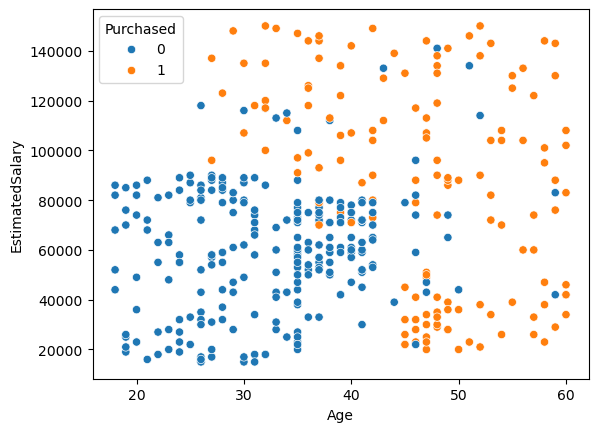

In [24]:
#visualization
#age vs purchase
sns.scatterplot(x=df["Age"],y=df["EstimatedSalary"],hue=df["Purchased"])
plt.show()

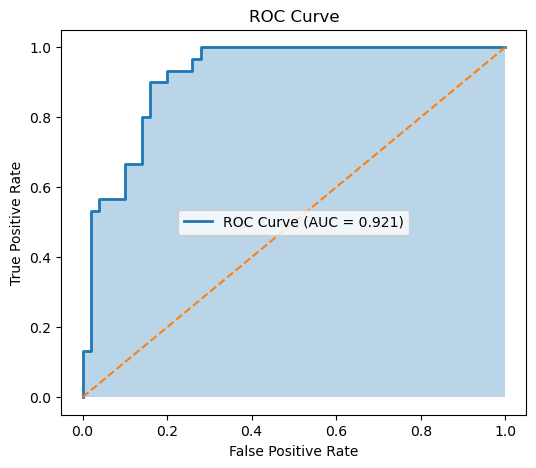

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

# predicted probabilities
y_prob = model.predict_proba(x_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

# ROC curve
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {auc_score:.3f})")

# Shaded AUC area
plt.fill_between(fpr, tpr, alpha=0.3)

# Random classifier line
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("Roc curve")
plt.show()

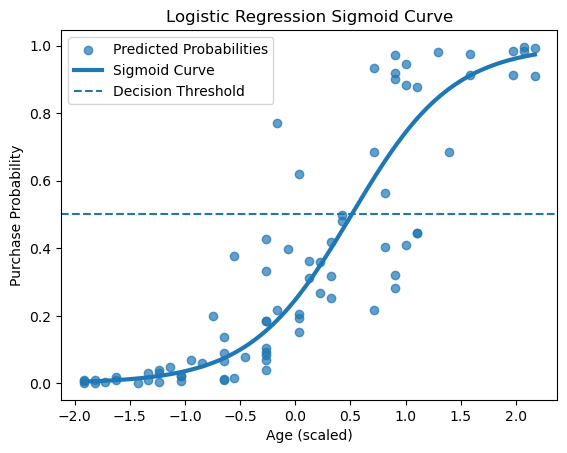

In [26]:
# predicted probabilities
y_prob = model.predict_proba(x_test)[:,1]

# scatter plot (actual probabilities)
plt.scatter(x_test[:,0], y_prob, alpha=0.7, label="Predicted Probabilities")

# create smooth range of Age values
age_range = np.linspace(x_train[:,0].min(), x_train[:,0].max(), 200)

# fix salary at mean
salary_mean = np.mean(x_train[:,1])

X_plot = np.c_[age_range, np.full_like(age_range, salary_mean)]

# predicted probability for curve
prob_curve = model.predict_proba(X_plot)[:,1]

# sigmoid curve
plt.plot(age_range, prob_curve, linewidth=3, label="Sigmoid Curve")

# decision threshold
plt.axhline(0.5, linestyle="--", label="Decision Threshold")

plt.xlabel("Age (scaled)")
plt.ylabel("Purchase Probability")
plt.title("Logistic Regression Sigmoid Curve")
plt.legend()
plt.savefig(
plt.show()
